# From data to a Fano factor

A common question: *do threshold crossings in my recording cluster or occur regularly, and is
that consistent with a Gaussian model?* The recipe is

1. cut the recording into windows of length $T$ and count crossings in each
   (`windowed_counts`, `empirical_fano`);
2. compare the windowed Fano factor with the model's **finite-window** prediction
   `fano_factor(u, T=window)`.

To keep the answer checkable, this notebook uses artificial data simulated from a known model:
a process with a rational-quadratic covariance ($\alpha = 0.75$), whose crossings cluster at
intermediate thresholds.

2,000,000 samples, spacing dt = 0.05


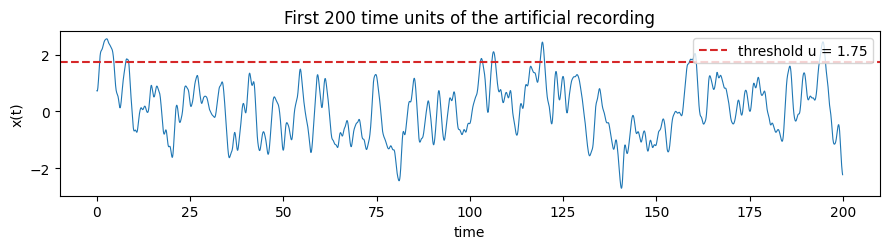

In [1]:
%matplotlib inline
import warnings

import numpy as np
import matplotlib.pyplot as plt
import torch

from gaussian_crossings import GaussianCrossings, empirical_fano, windowed_counts
from gaussian_crossings.process import r_rational_quadratic
from gaussian_crossings.utils import simulate_gaussian_process_fft

params = dict(sigma=1.0, tau=1.0, alpha=0.75)
dt = 0.05

torch.manual_seed(2026)  # artificial data: reproducible
time, x = simulate_gaussian_process_fft(r_rational_quadratic, 1e5, dt, **params)
x = x.numpy()
print(f"{x.size:,} samples, spacing dt = {dt}")

fig, ax = plt.subplots(figsize=(9, 2.6))
ax.plot(time[:4000], x[:4000], lw=0.8)
ax.axhline(1.75, color="tab:red", linestyle="--", label="threshold u = 1.75")
ax.set(xlabel="time", ylabel="x(t)", title="First 200 time units of the artificial recording")
ax.legend(loc="upper right")
fig.tight_layout()

## Counting crossings in windows

Each crossing belongs to exactly one window. With windows of 100 time units the recording gives
about 1,000 windows.

In [2]:
window = 100.0
counts = windowed_counts(x, 1.75, window=window, dt=dt)
print("windows:", counts.size)
print("first ten counts:", counts[:10])
print(f"mean {counts.mean():.2f}, variance {counts.var(ddof=1):.2f}, "
      f"Fano factor {counts.var(ddof=1) / counts.mean():.3f}")

windows: 999
first ten counts: [2 5 3 3 2 3 1 4 6 6]
mean 3.45, variance 4.31, Fano factor 1.248


## Fano factor with confidence intervals at many thresholds

`empirical_fano` returns the estimate, a bootstrap confidence interval over windows, and a
standard error.

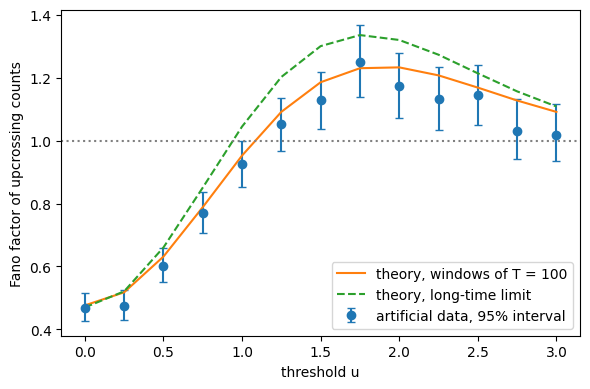

In [3]:
levels = np.linspace(0.0, 3.0, 13)
estimate = empirical_fano(x, levels, window=window, dt=dt, seed=0)

model = GaussianCrossings(r_rational_quadratic, **params)
finite_window = model.fano_factor(levels, T=window)
long_time = model.fano_factor(levels)

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(levels, estimate.fano,
            yerr=[estimate.fano - estimate.ci_low, estimate.ci_high - estimate.fano],
            fmt="o", capsize=3, label="artificial data, 95% interval")
ax.plot(levels, finite_window, label=f"theory, windows of T = {window:g}")
ax.plot(levels, long_time, linestyle="--", label="theory, long-time limit")
ax.axhline(1.0, color="gray", linestyle=":")
ax.set(xlabel="threshold u", ylabel="Fano factor of upcrossing counts")
ax.legend()
fig.tight_layout()

The data follow the finite-window prediction. The long-time limit lies about 10% higher at
intermediate thresholds: windows of 100 time units are not long enough to capture the slowly
decaying correlations of this process. Comparing data with the long-time value would suggest a
discrepancy that is not there.

The bootstrap treats windows as independent. That is accurate when windows are much longer than
the correlation time; for strongly correlated windows the interval is too narrow.

## Sampling too coarsely misses crossings

Two crossings that fall between consecutive samples are invisible. `empirical_fano` recounts
with every second sample and warns when that removes more than 2% of the crossings.

In [4]:
coarse = x[::10]  # spacing 0.5 instead of 0.05
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    empirical_fano(coarse, 1.75, window=window, dt=10 * dt, seed=0)
for warning in caught:
    print(f"{warning.category.__name__}: {warning.message}")

## Practical checklist

- Use windows much longer than the correlation time, and at least a few hundred of them.
- Sample finely enough that halving the sampling rate barely changes the counts.
- Compare with `fano_factor(u, T=window)` using the same window length as the data.